In [ ]:
!pip install open-clip-torch
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import open_clip

from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from sklearn.metrics import classification_report, confusion_matrix

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.3 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Đường dẫn  liệu
DATASET_PATH = "/content/drive/MyDrive/BRACoL"
IMAGE_DIR    = "/content/drive/MyDrive/coffee-datasets/coffee-datasets/leaf/images" # Đường dẫn folder chứa tệp .jpg
LABEL_FILE   = "/content/drive/MyDrive/coffee-datasets/coffee-datasets/leaf/dataset.csv"

SEVERITY_CLASSES = ['Healthy', 'Very Low', 'Low', 'High', 'Very High']
NUM_CLASSES      = len(SEVERITY_CLASSES)

CLIP_MODEL   = "ViT-B-32"
PRETRAINED   = "openai"
IMAGE_SIZE   = 224

BATCH_SIZE   = 32
EPOCHS       = 30
LR           = 1e-4
WEIGHT_DECAY = 1e-4


TRAIN_RATIO  = 0.70
VAL_RATIO    = 0.15
SEED         = 42

SAVE_PATH    = "/content/drive/MyDrive/clip_severity_2a_best.pt"

torch.manual_seed(SEED)
np.random.seed(SEED)
if DEVICE == "cuda":
    torch.cuda.manual_seed_all(SEED)

print(f"Số lượng lớp dự đoán: {NUM_CLASSES} (Mức độ nghiêm trọng)")

Số lượng lớp dự đoán: 5 (Mức độ nghiêm trọng)


In [ ]:
class CoffeeDataset(Dataset):
    def __init__(self, samples, augment=False):
        self.samples   = samples
        self.augment   = augment
        self.normalize = transforms.Normalize(
            mean=(0.48145466, 0.4578275,  0.40821073),
            std =(0.26862954, 0.26130258, 0.27577711),
        )
        self.base_transform = transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.ToTensor(),
        ])
        self.aug_transform = transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        if self.augment:
            image = self.aug_transform(image)
        else:
            image = self.base_transform(image)
        image = self.normalize(image)
        return image, label

In [ ]:
# df_labels là dataframe chứa file csv của bạn
class_counts = df_labels['severity'].value_counts().sort_index()

print("Thống kê số lượng mẫu từng class (Severity):")
for idx, count in class_counts.items():
    print(f"Mức {idx} ({SEVERITY_CLASSES[idx]}): {count} mẫu")

Thống kê số lượng mẫu từng class (Severity):
Mức 0 (Healthy): 272 mẫu
Mức 1 (Very Low): 924 mẫu
Mức 2 (Low): 332 mẫu
Mức 3 (High): 101 mẫu
Mức 4 (Very High): 56 mẫu


In [ ]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split

SEED = 42
df_labels = pd.read_csv(LABEL_FILE)

df_labels = df_labels[df_labels['predominant_stress'] <= 4].copy()

train_df, temp_df = train_test_split(
    df_labels, test_size=0.3, stratify=df_labels['severity'], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['severity'], random_state=SEED
)

def get_path(img_id):
    return os.path.join(IMAGE_DIR, f"{int(img_id)}.jpg")

train_samples = list(zip(train_df['id'].apply(get_path), train_df['severity']))
val_samples   = list(zip(val_df['id'].apply(get_path), val_df['severity']))
test_samples  = list(zip(test_df['id'].apply(get_path), test_df['severity']))

print(f"Train={len(train_samples)}, Val={len(val_samples)}, Test={len(test_samples)}")

Train=1179, Val=253, Test=253


In [ ]:
train_loader = DataLoader(
    CoffeeDataset(train_samples, augment=True),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    CoffeeDataset(val_samples, augment=False),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    CoffeeDataset(test_samples, augment=False),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [ ]:
class CLIPClassifier(nn.Module):
    def __init__(self, unfreeze_last_n=4):
        super().__init__()
        clip_model, _, _ = open_clip.create_model_and_transforms(
            CLIP_MODEL, pretrained=PRETRAINED)
        self.visual_encoder = clip_model.visual

        for param in self.visual_encoder.parameters():
            param.requires_grad = False

        for block in self.visual_encoder.transformer.resblocks[-unfreeze_last_n:]:
            for param in block.parameters():
                param.requires_grad = True

        self.classifier = nn.Sequential(
            nn.LayerNorm(512),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, NUM_CLASSES),
        )

    def forward(self, x):
        features = self.visual_encoder(x)
        return self.classifier(features)

In [ ]:
model = CLIPClassifier(unfreeze_last_n=4).to(DEVICE)

open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


In [ ]:
class_counts = [272, 924, 332, 101, 56]
weights = torch.tensor([1/c for c in class_counts], dtype=torch.float32)
weights = weights / weights.sum() * len(class_counts)
criterion = nn.CrossEntropyLoss(weight=weights.to(DEVICE), label_smoothing=0.1)

# 1. Tách các tham số của backbone và head
backbone_params = []
head_params = []

for name, param in model.named_parameters():
    if param.requires_grad:
        # Dựa trên danh sách bạn gửi, backbone bắt đầu bằng "visual_encoder"
        if "visual_encoder" in name:
            backbone_params.append(param)
        # Các lớp còn lại (thường là "classifier") sẽ thuộc về head
        else:
            head_params.append(param)

# 2. Thiết lập Optimizer với tốc độ học khác biệt (Discriminative LR)
optimizer = optim.AdamW([
    {'params': backbone_params, 'lr': 1e-5}, # Backbone CLIP học rất chậm
    {'params': head_params, 'lr': 1e-4}      # Head phân loại (classifier) học nhanh hơn
], weight_decay=WEIGHT_DECAY)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=1e-6)

In [ ]:
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "val_mae": [], "val_obo": []}
best_val_mae = float('inf')

for epoch in range(1, EPOCHS + 1):
    # --- PHASE: TRAIN ---
    model.train()
    train_loss = train_correct = train_total = 0
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()
        train_total += images.size(0)

    # --- PHASE: EVAL ---
    model.eval()
    val_loss = val_correct = val_total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            val_loss += criterion(outputs, labels).item() * images.size(0)

            preds = outputs.argmax(1)
            val_correct += (preds == labels).sum().item()
            val_total += images.size(0)

            # Đưa về CPU và chuyển sang list ngay
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    # Kiểm tra an toàn trước khi tính toán các chỉ số Severity
    if len(all_preds) > 0:
        all_preds_np = np.array(all_preds)
        all_labels_np = np.array(all_labels)

        v_mae = mean_absolute_error(all_labels_np, all_preds_np)
        v_obo = (np.abs(all_preds_np - all_labels_np) <= 1).mean()
    else:
        v_mae = 0.0
        v_obo = 0.0

    t_loss = train_loss / train_total
    t_acc = train_correct / train_total
    v_loss = val_loss / val_total
    v_acc = val_correct / val_total

    scheduler.step()

    # Lưu lịch sử
    history["train_loss"].append(t_loss)
    history["train_acc"].append(t_acc)
    history["val_loss"].append(v_loss)
    history["val_acc"].append(v_acc)
    history["val_mae"].append(v_mae)
    history["val_obo"].append(v_obo)

    saved = ""
    if v_mae < best_val_mae:
        best_val_mae = v_mae
        torch.save({"epoch": epoch, "state_dict": model.state_dict(),
                    "val_mae": v_mae, "val_acc": v_acc}, SAVE_PATH)
        saved = " <- best MAE saved"

    print(f"[{epoch:02d}/{EPOCHS}] "
          f"loss: {t_loss:.4f} acc: {t_acc:.4f} | "
          f"val_loss: {v_loss:.4f} val_acc: {v_acc:.4f} MAE: {v_mae:.4f} OBO: {v_obo:.4f}{saved}")

[01/30] loss: 1.3193 acc: 0.7040 | val_loss: 1.2945 val_acc: 0.6285 MAE: 0.6126 OBO: 0.8142 <- best MAE saved
[02/30] loss: 1.2527 acc: 0.7260 | val_loss: 1.2544 val_acc: 0.8182 MAE: 0.1897 OBO: 0.9921 <- best MAE saved
[03/30] loss: 1.1840 acc: 0.7939 | val_loss: 1.2170 val_acc: 0.8024 MAE: 0.2055 OBO: 0.9921
[04/30] loss: 1.1161 acc: 0.8287 | val_loss: 1.1568 val_acc: 0.7589 MAE: 0.2569 OBO: 0.9881
[05/30] loss: 1.0144 acc: 0.8524 | val_loss: 1.1830 val_acc: 0.7273 MAE: 0.2806 OBO: 0.9921
[06/30] loss: 1.0515 acc: 0.8439 | val_loss: 1.1588 val_acc: 0.8024 MAE: 0.2095 OBO: 0.9881
[07/30] loss: 1.0457 acc: 0.8592 | val_loss: 1.1531 val_acc: 0.7787 MAE: 0.2332 OBO: 0.9881
[08/30] loss: 1.0079 acc: 0.8634 | val_loss: 1.1184 val_acc: 0.8142 MAE: 0.1937 OBO: 0.9921
[09/30] loss: 0.9653 acc: 0.8821 | val_loss: 1.1424 val_acc: 0.8261 MAE: 0.1818 OBO: 0.9921 <- best MAE saved
[10/30] loss: 0.9353 acc: 0.8957 | val_loss: 1.1371 val_acc: 0.8221 MAE: 0.1858 OBO: 0.9921
[11/30] loss: 0.9558 acc: 

In [ ]:
print(f"Số lượng mẫu tập Train: {len(train_samples)}")
print(f"Số lượng mẫu tập Val: {len(val_samples)}")
print(f"Số lượng mẫu tập Test: {len(test_samples)}")

# Thử lấy 1 batch từ val_loader để xem có chạy được không
try:
    data_iter = iter(val_loader)
    images, labels = next(data_iter)
    print(f"Batch đầu tiên của Val OK: {images.shape}, {labels.shape}")
except StopIteration:
    print("LỖI CỰC NẶNG: val_loader không có dữ liệu!")
except Exception as e:
    print(f"Lỗi khác khi load data: {e}")

Số lượng mẫu tập Train: 1179
Số lượng mẫu tập Val: 253
Số lượng mẫu tập Test: 253
Batch đầu tiên của Val OK: torch.Size([32, 3, 224, 224]), torch.Size([32])


In [ ]:
for name, _ in model.named_parameters():
    print(name)

visual_encoder.class_embedding
visual_encoder.positional_embedding
visual_encoder.proj
visual_encoder.conv1.weight
visual_encoder.ln_pre.weight
visual_encoder.ln_pre.bias
visual_encoder.transformer.resblocks.0.ln_1.weight
visual_encoder.transformer.resblocks.0.ln_1.bias
visual_encoder.transformer.resblocks.0.attn.in_proj_weight
visual_encoder.transformer.resblocks.0.attn.in_proj_bias
visual_encoder.transformer.resblocks.0.attn.out_proj.weight
visual_encoder.transformer.resblocks.0.attn.out_proj.bias
visual_encoder.transformer.resblocks.0.ln_2.weight
visual_encoder.transformer.resblocks.0.ln_2.bias
visual_encoder.transformer.resblocks.0.mlp.c_fc.weight
visual_encoder.transformer.resblocks.0.mlp.c_fc.bias
visual_encoder.transformer.resblocks.0.mlp.c_proj.weight
visual_encoder.transformer.resblocks.0.mlp.c_proj.bias
visual_encoder.transformer.resblocks.1.ln_1.weight
visual_encoder.transformer.resblocks.1.ln_1.bias
visual_encoder.transformer.resblocks.1.attn.in_proj_weight
visual_encoder.t

In [ ]:
# ── Cell 11: Evaluate on Test Set ──────────────────────────────────
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, mean_absolute_error,
                              f1_score, cohen_kappa_score)
import numpy as np

# 1. Load best checkpoint
checkpoint = torch.load(SAVE_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint['state_dict'])
model.eval()

test_preds, test_labels = [], []

# 2. Inference trên Test set
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        preds   = outputs.argmax(1).cpu().numpy()
        test_preds.extend(preds)
        test_labels.extend(labels.numpy())

test_preds  = np.array(test_preds)
test_labels = np.array(test_labels)

# 3. Metrics
acc     = accuracy_score(test_labels, test_preds)
mae     = mean_absolute_error(test_labels, test_preds)
macro_f1= f1_score(test_labels, test_preds, average='macro', zero_division=0)
kappa   = cohen_kappa_score(test_labels, test_preds, weights='quadratic')

# Off-by-one accuracy: chấp nhận sai tối đa 1 bậc
obo_acc = float((np.abs(test_preds - test_labels) <= 1).mean())

# Per-class accuracy
print("=" * 52)
print("   KẾT QUẢ TRÊN TẬP TEST — TN2a (Severity CE)   ")
print("=" * 52)
print(f"  Accuracy        : {acc:.4f}")
print(f"  Macro F1        : {macro_f1:.4f}")
print(f"  MAE             : {mae:.4f}")
print(f"  Off-by-1 Acc    : {obo_acc:.4f}  ← sai tối đa 1 bậc")
print(f"  Quadratic Kappa : {kappa:.4f}  ← penalty nhầm xa")
print("-" * 52)

print("\nClassification Report:")
print(classification_report(
    test_labels, test_preds,
    target_names=SEVERITY_CLASSES,
    digits=4, zero_division=0
))

# Phân phối prediction vs ground truth
print("Phân phối prediction vs ground truth:")
print(f"  {'Class':<12} {'GT':>6} {'Pred':>6}")
print(f"  {'-'*26}")
from collections import Counter
gt_cnt   = Counter(test_labels)
pred_cnt = Counter(test_preds)
for i, name in enumerate(SEVERITY_CLASSES):
    gt   = gt_cnt.get(i, 0)
    pred = pred_cnt.get(i, 0)
    flag = " ← bị bỏ!" if pred == 0 and gt > 0 else ""
    print(f"  {name:<12} {gt:>6} {pred:>6}{flag}")

   KẾT QUẢ TRÊN TẬP TEST — TN2a (Severity CE)   
  Accuracy        : 0.8379
  Macro F1        : 0.6884
  MAE             : 0.1700
  Off-by-1 Acc    : 0.9921  ← sai tối đa 1 bậc
  Quadratic Kappa : 0.8770  ← penalty nhầm xa
----------------------------------------------------

Classification Report:
              precision    recall  f1-score   support

     Healthy     0.9762    1.0000    0.9880        41
    Very Low     0.8859    0.9496    0.9167       139
         Low     0.6667    0.6000    0.6316        50
        High     0.5000    0.4000    0.4444        15
   Very High     0.6000    0.3750    0.4615         8

    accuracy                         0.8379       253
   macro avg     0.7258    0.6649    0.6884       253
weighted avg     0.8253    0.8379    0.8295       253

Phân phối prediction vs ground truth:
  Class            GT   Pred
  --------------------------
  Healthy          41     42
  Very Low        139    149
  Low              50     45
  High             15     12

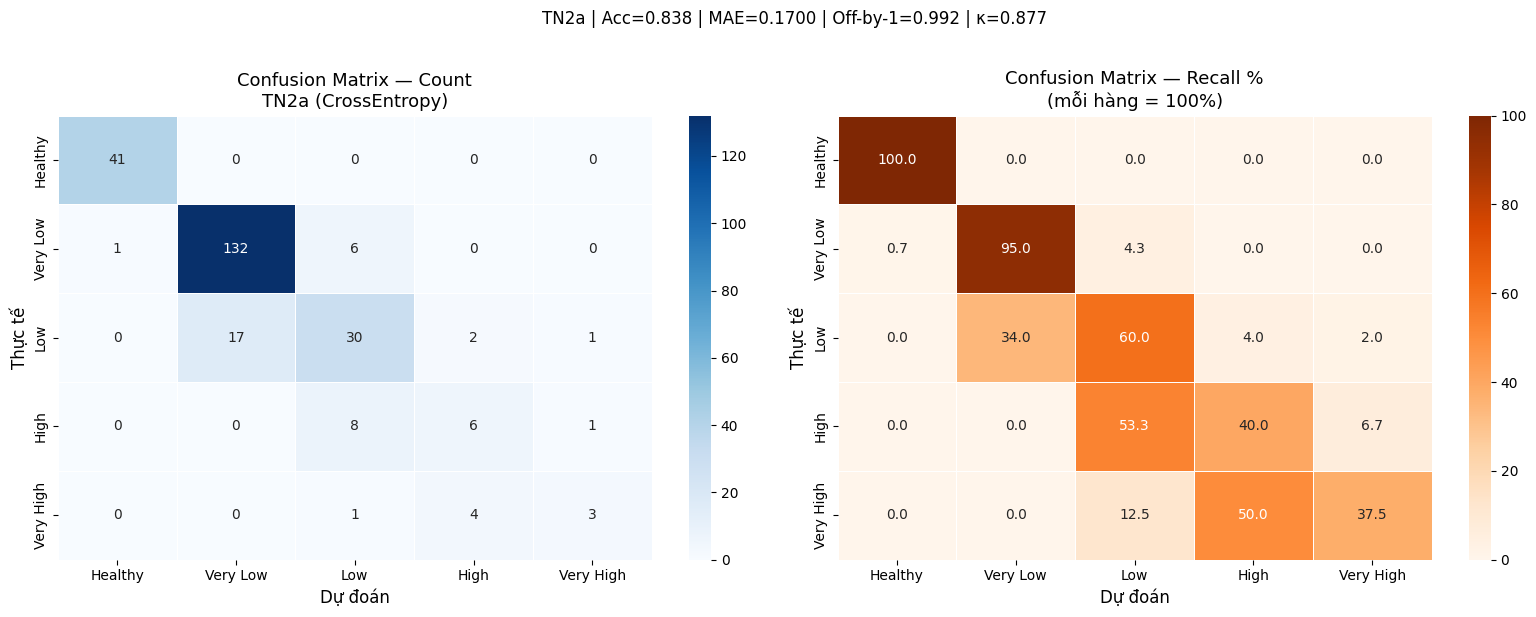


Phân tích hướng nhầm lẫn:
  Predict THẤP hơn thực tế (under):   31 mẫu  ← nguy hiểm: bệnh nặng bị đánh giá nhẹ
  Predict ĐÚNG                     :  212 mẫu
  Predict CAO hơn thực tế (over)   :   10 mẫu

Recall từng mức severity:
  Healthy   : 100.0%  (0/41 sai)  
  Very Low  :  95.0%  (7/139 sai)  
  Low       :  60.0%  (20/50 sai)  
  High      :  40.0%  (9/15 sai)  ← cần cải thiện
  Very High :  37.5%  (5/8 sai)  ← cần cải thiện


In [ ]:
# ── Cell 12: Confusion Matrix + Error Analysis ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Plot 1: Confusion matrix (count) ─────────────────────────────
cm = confusion_matrix(test_labels, test_preds,
                      labels=list(range(len(SEVERITY_CLASSES))))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=SEVERITY_CLASSES,
            yticklabels=SEVERITY_CLASSES,
            linewidths=0.5)
axes[0].set_xlabel('Dự đoán',  fontsize=12)
axes[0].set_ylabel('Thực tế',  fontsize=12)
axes[0].set_title('Confusion Matrix — Count\nTN2a (CrossEntropy)', fontsize=13)

# ── Plot 2: Confusion matrix (% theo hàng = recall từng class) ───
cm_norm = cm.astype(float)
row_sum = cm_norm.sum(axis=1, keepdims=True)
row_sum[row_sum == 0] = 1           # tránh chia 0
cm_norm = cm_norm / row_sum * 100   # % recall

sns.heatmap(cm_norm, annot=True, fmt='.1f', cmap='Oranges', ax=axes[1],
            xticklabels=SEVERITY_CLASSES,
            yticklabels=SEVERITY_CLASSES,
            linewidths=0.5,
            vmin=0, vmax=100)
axes[1].set_xlabel('Dự đoán',  fontsize=12)
axes[1].set_ylabel('Thực tế',  fontsize=12)
axes[1].set_title('Confusion Matrix — Recall %\n(mỗi hàng = 100%)', fontsize=13)

plt.suptitle(
    f'TN2a | Acc={acc:.3f} | MAE={mae:.4f} | Off-by-1={obo_acc:.3f} | κ={kappa:.3f}',
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.savefig('cm_TN2a.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Phân tích lỗi theo hướng ─────────────────────────────────────
print("\nPhân tích hướng nhầm lẫn:")
errors = test_preds - test_labels           # âm = predict thấp hơn thực tế
print(f"  Predict THẤP hơn thực tế (under): {(errors < 0).sum():>4} mẫu  "
      f"← nguy hiểm: bệnh nặng bị đánh giá nhẹ")
print(f"  Predict ĐÚNG                     : {(errors == 0).sum():>4} mẫu")
print(f"  Predict CAO hơn thực tế (over)   : {(errors > 0).sum():>4} mẫu")

# Severity cao nhất bị nhầm nhiều nhất
print("\nRecall từng mức severity:")
for i, name in enumerate(SEVERITY_CLASSES):
    mask    = test_labels == i
    if mask.sum() == 0:
        continue
    recall  = (test_preds[mask] == i).mean()
    n_total = mask.sum()
    n_wrong = (test_preds[mask] != i).sum()
    print(f"  {name:<10}: {recall*100:5.1f}%  "
          f"({n_wrong}/{n_total} sai)  "
          f"{'← cần cải thiện' if recall < 0.5 else ''}")